In [1]:
!pip uninstall -y tensorflow keras numpy

Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: keras 3.13.2
Uninstalling keras-3.13.2:
  Successfully uninstalled keras-3.13.2
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


In [1]:
!pip uninstall -y jax jaxlib ml_dtypes tensorflow keras numpy

!pip install tensorflow==2.16.2 keras==3.3.3 numpy==1.26.4 ml-dtypes==0.3.2

Found existing installation: ml-dtypes 0.3.2
Uninstalling ml-dtypes-0.3.2:
  Successfully uninstalled ml-dtypes-0.3.2
Found existing installation: tensorflow 2.16.2
Uninstalling tensorflow-2.16.2:
  Successfully uninstalled tensorflow-2.16.2
Found existing installation: keras 3.3.3
Uninstalling keras-3.3.3:
  Successfully uninstalled keras-3.3.3
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached tensorflow-2.16.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.2 kB)
  Using cached keras-3.3.3-py3-none-any.whl.metadata (5.7 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached ml_dtypes-0.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached tensorflow-2.16.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (590.8 MB)
Using cached keras-3.3.3-py3-none-any.whl (1.1 MB)
Using ca

In [1]:
import tensorflow as tf
import numpy as np

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.16.2
NumPy: 1.26.4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from scipy import stats
import statsmodels.api as sm

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [4]:
base_path = "/content/drive/MyDrive/Wallmart"

data = pd.read_csv(f"{base_path}/train.csv")
stores = pd.read_csv(f"{base_path}/stores.csv")
features = pd.read_csv(f"{base_path}/features.csv")

In [5]:
# Show datasets
print("Train Info:")
data.info()

print("\nStores Info:")
stores.info()

print("\nFeatures Info:")
features.info()

Train Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB

Stores Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB

Features Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null C

Data Preprocessing

In [6]:
# Handle Missing Values
features["CPI"].fillna(features["CPI"].median(), inplace=True)
features["Unemployment"].fillna(features["Unemployment"].median(), inplace=True)

for i in range(1,6):
    features["MarkDown"+str(i)] = features["MarkDown"+str(i)].apply(lambda x: 0 if x < 0 else x)
    features["MarkDown"+str(i)].fillna(0, inplace=True)

In [7]:
# Merge Datasets
data = pd.merge(data, stores, on='Store', how='left')
data = pd.merge(data, features, on=['Store','Date'], how='left')

# Fix IsHoliday duplication
data['IsHoliday'] = data['IsHoliday_x']
data.drop(['IsHoliday_x', 'IsHoliday_y'], axis=1, inplace=True)

# Date conversion
data['Date'] = pd.to_datetime(data['Date'])
data.sort_values(by='Date', inplace=True)
data.set_index('Date', inplace=True)

In [8]:
# Feature Engineering
data['Year'] = data.index.year
data['Month'] = data.index.month
data['Week'] = data.index.isocalendar().week

In [9]:
# Remove Outliers
numeric_col = ['Weekly_Sales','Size','Temperature','Fuel_Price','CPI','Unemployment']
data = data[(np.abs(stats.zscore(data[numeric_col])) < 2.5).all(axis=1)]

In [10]:
# Remove Negative Sales
data = data[data['Weekly_Sales'] >= 0]

EDA & VISUALIZATION

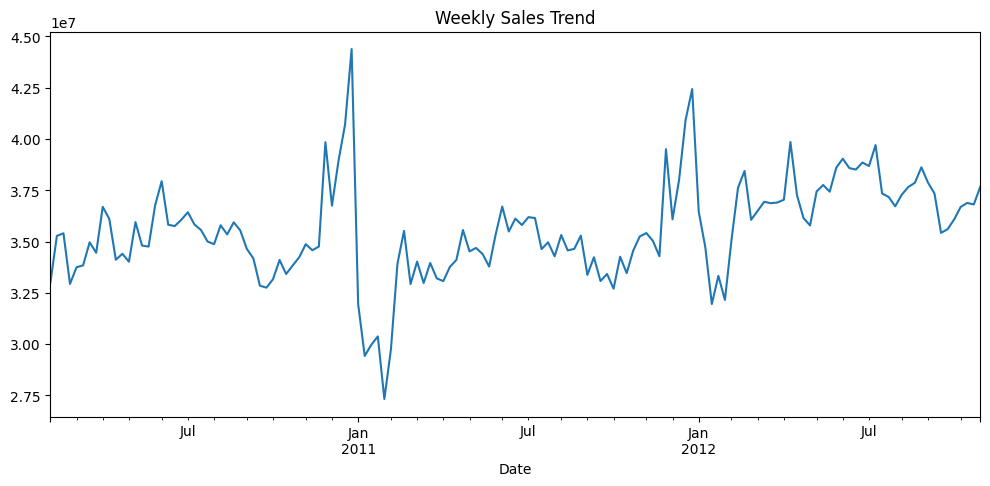

In [11]:
# Weekly Sales Trend
plt.figure(figsize=(12,5))
data['Weekly_Sales'].resample('W').sum().plot()
plt.title("Weekly Sales Trend")
plt.show()

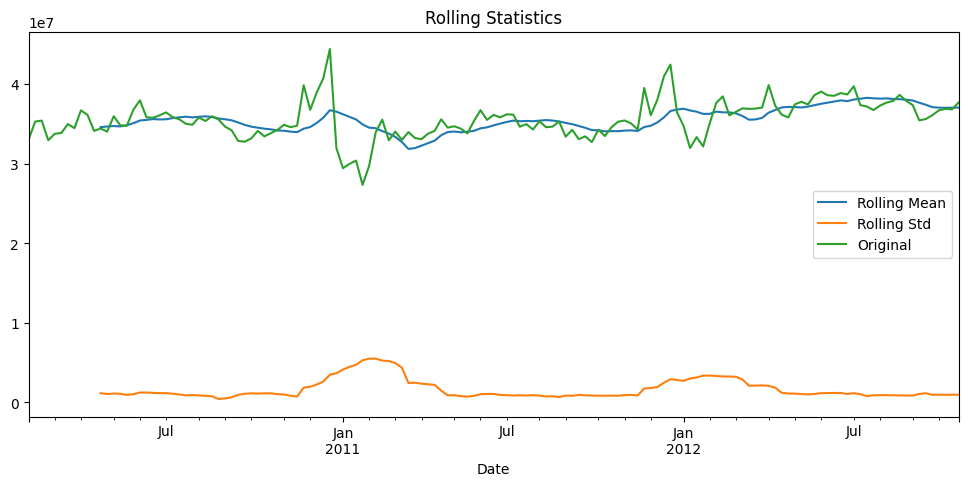

In [12]:
# Rolling Statistics
ts = data.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(12,5))
ts.rolling(12).mean().plot(label='Rolling Mean')
ts.rolling(12).std().plot(label='Rolling Std')
ts.plot(label='Original')
plt.legend()
plt.title("Rolling Statistics")
plt.show()

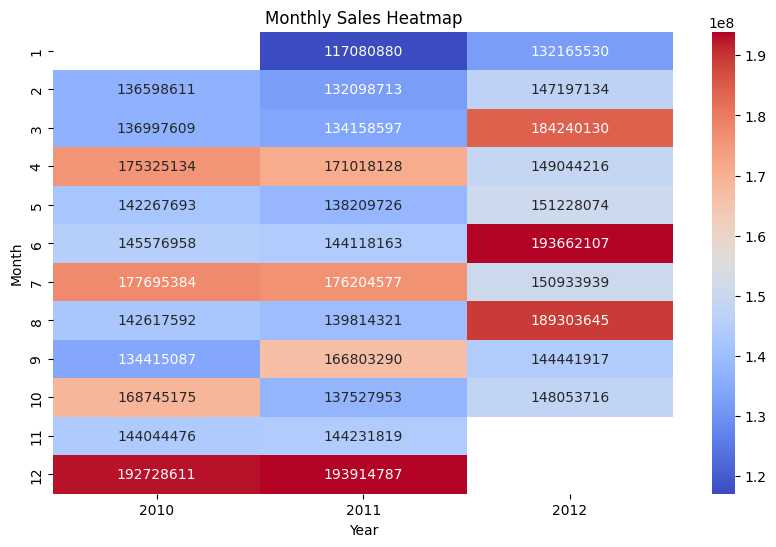

In [13]:
# Monthly Heatmap
pivot = data.pivot_table(values='Weekly_Sales', index='Month', columns='Year', aggfunc='sum')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap='coolwarm', annot=True, fmt=".0f")
plt.title("Monthly Sales Heatmap")
plt.show()

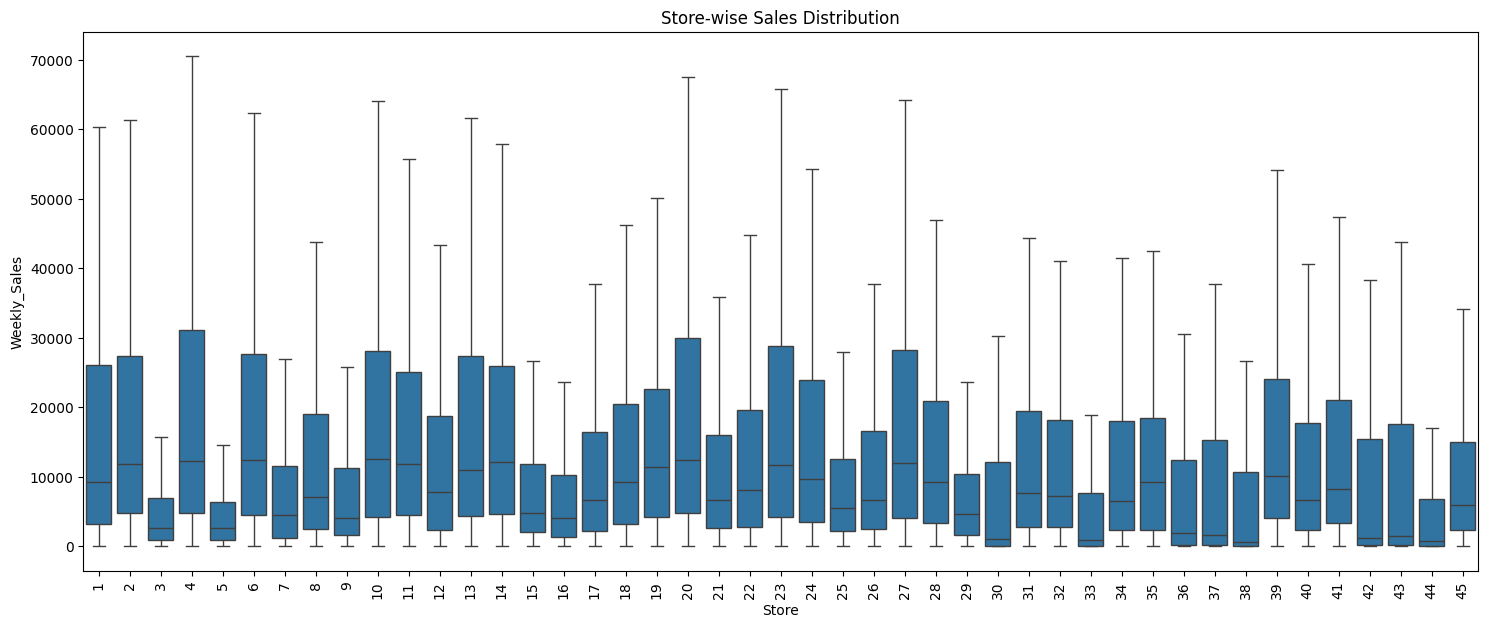

In [14]:
# Store-wise Distribution
plt.figure(figsize=(18,7))
sns.boxplot(x='Store', y='Weekly_Sales', data=data, showfliers=False)
plt.xticks(rotation=90)
plt.title("Store-wise Sales Distribution")
plt.show()

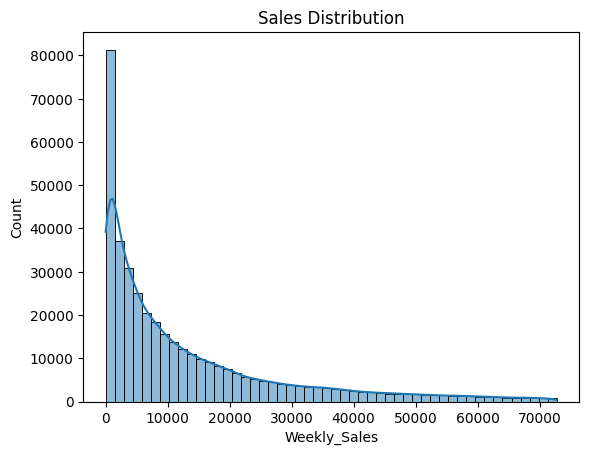

In [15]:
# Sales Distribution
sns.histplot(data['Weekly_Sales'], bins=50, kde=True)
plt.title("Sales Distribution")
plt.show()

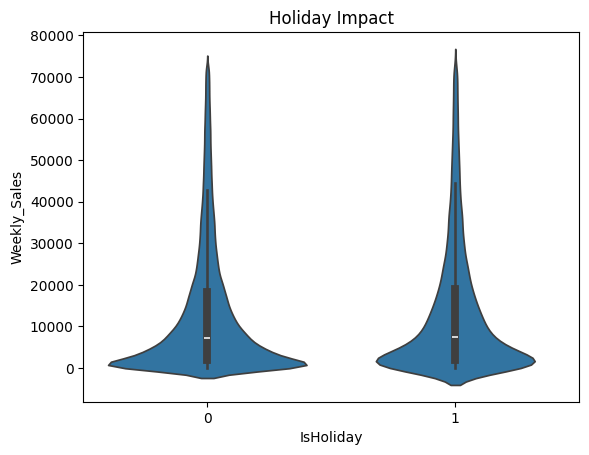

In [16]:
# Holiday Effect
data['IsHoliday'] = data['IsHoliday'].astype(int)

sns.violinplot(x='IsHoliday', y='Weekly_Sales', data=data)
plt.title("Holiday Impact")
plt.show()

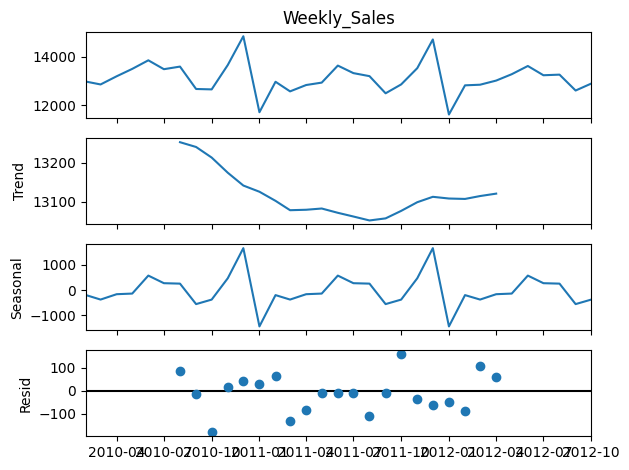

In [17]:
# Seasonal Decomposition
sm.tsa.seasonal_decompose(
    data['Weekly_Sales'].resample('MS').mean(),
    model='additive'
).plot()
plt.show()

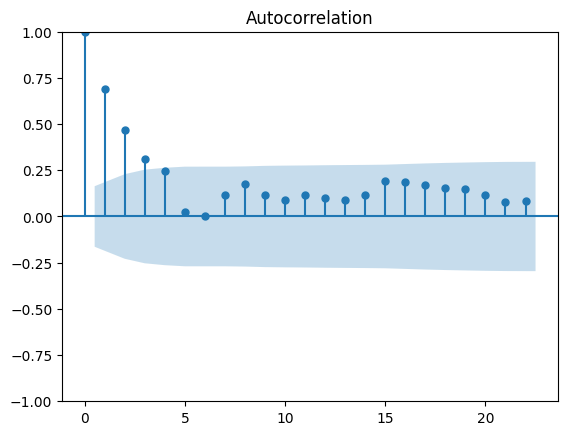

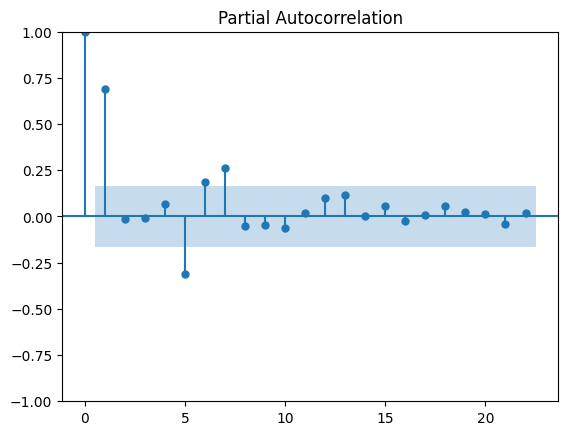

In [18]:
# ACF & PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ts)
plot_pacf(ts)
plt.show()

In [19]:
# Time Series Preparation
ts = ts.resample('W').sum()

train_size = int(len(ts)*0.8)
train_ts = ts[:train_size]
test_ts = ts[train_size:]

In [20]:
# Arima model
arima_model = ARIMA(train_ts, order=(5,1,0))
arima_result = arima_model.fit()

arima_pred = arima_result.forecast(len(test_ts))

arima_rmse = np.sqrt(mean_squared_error(test_ts, arima_pred))
arima_mae = mean_absolute_error(test_ts, arima_pred)

print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAE:", arima_mae)

ARIMA RMSE: 2306540.7608108246
ARIMA MAE: 2051581.3762784149


In [21]:
# Sarima
sarima_model = SARIMAX(train_ts,
                       order=(1,1,1),
                       seasonal_order=(1,1,1,52))

sarima_result = sarima_model.fit()

sarima_pred = sarima_result.forecast(len(test_ts))

sarima_rmse = np.sqrt(mean_squared_error(test_ts, sarima_pred))
sarima_mae = mean_absolute_error(test_ts, sarima_pred)

print("SARIMA RMSE:", sarima_rmse)
print("SARIMA MAE:", sarima_mae)

SARIMA RMSE: 2643820.379298128
SARIMA MAE: 2552882.6859999737


In [22]:
# LSTM
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(ts.values.reshape(-1,1))

In [23]:
# Create Sequence
def create_dataset(data, time_step=10):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data, 10)
X = X.reshape(X.shape[0], X.shape[1], 1)

In [24]:
train_size = int(len(X)*0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [25]:
# Build model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(10,1)))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(loss='mse', optimizer='adam')
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.2187
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1047
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0325
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0392
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0410
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0231
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0290
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0245
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0264
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0232
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0238
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0239
Epoch 13/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0221
Epoch 14/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0234
Epoch 15/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0219
Epoch 16/20
4/4 ━━━━━━━━━━━━━━━━━━

In [26]:
lstm_pred = model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))
lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)

print("LSTM RMSE:", lstm_rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step
LSTM RMSE: 1592195.1388681221


In [27]:
results = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA", "LSTM"],
    "RMSE": [arima_rmse, sarima_rmse, lstm_rmse],
    "MAE": [arima_mae, sarima_mae, lstm_mae]
})

print(results)

    Model          RMSE           MAE
0   ARIMA  2.306541e+06  2.051581e+06
1  SARIMA  2.643820e+06  2.552883e+06
2    LSTM  1.592195e+06  1.316411e+06


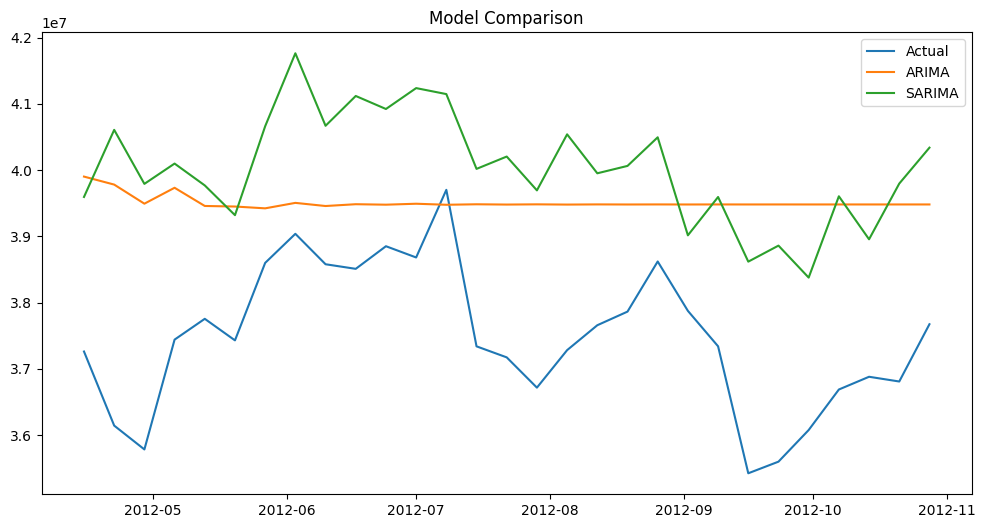

In [28]:
plt.figure(figsize=(12,6))
plt.plot(test_ts.index, test_ts.values, label='Actual')
plt.plot(test_ts.index, arima_pred, label='ARIMA')
plt.plot(test_ts.index, sarima_pred, label='SARIMA')
plt.legend()
plt.title("Model Comparison")
plt.show()

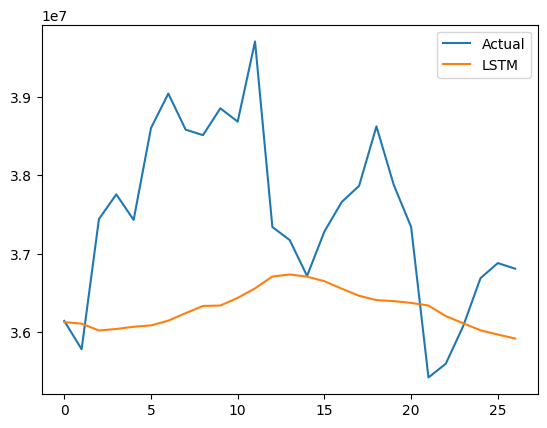

In [29]:
# LSTM and actual
plt.plot(y_test_actual, label='Actual')
plt.plot(lstm_pred, label='LSTM')
plt.legend()
plt.show()


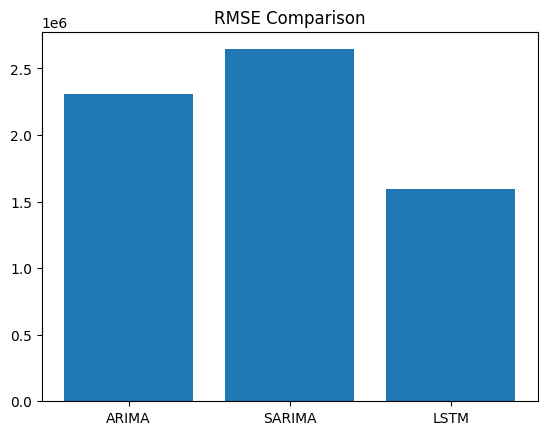

In [30]:
# Error comparison
models = ['ARIMA','SARIMA','LSTM']
rmse = [arima_rmse, sarima_rmse, lstm_rmse]

plt.bar(models, rmse)
plt.title("RMSE Comparison")
plt.show()

In [31]:
# Forecasting 50 days
forecast_steps_50 = 7

In [32]:
# Arima
arima_50 = arima_result.forecast(steps=forecast_steps_50)
# Sarima
sarima_50 = sarima_result.forecast(steps=forecast_steps_50)

#LSTM 50 days
def lstm_future(model, data, steps):
    temp = list(data[-10:])
    output = []

    for _ in range(steps):
        x_input = np.array(temp[-10:]).reshape(1,10,1)
        yhat = model.predict(x_input, verbose=0)
        temp.append(yhat[0][0])
        output.append(yhat[0][0])

    return np.array(output)

lstm_50 = lstm_future(model, scaled_data.flatten(), forecast_steps_50)
lstm_50 = scaler.inverse_transform(lstm_50.reshape(-1,1))

In [33]:
# Create future dates
future_50_dates = pd.date_range(
    start=ts.index[-1],
    periods=forecast_steps_50+1,
    freq='W'
)[1:]

In [34]:
arima_50.index = future_50_dates
sarima_50.index = future_50_dates

In [35]:
arima_full = pd.concat([
    pd.Series(arima_pred, index=test_ts.index),
    arima_50
])

sarima_full = pd.concat([
    pd.Series(sarima_pred, index=test_ts.index),
    sarima_50
])


lstm_index = test_ts.index[-len(lstm_pred):]

lstm_full = pd.concat([
    pd.Series(lstm_pred.flatten(), index=lstm_index),
    pd.Series(lstm_50.flatten(), index=future_50_dates)
])

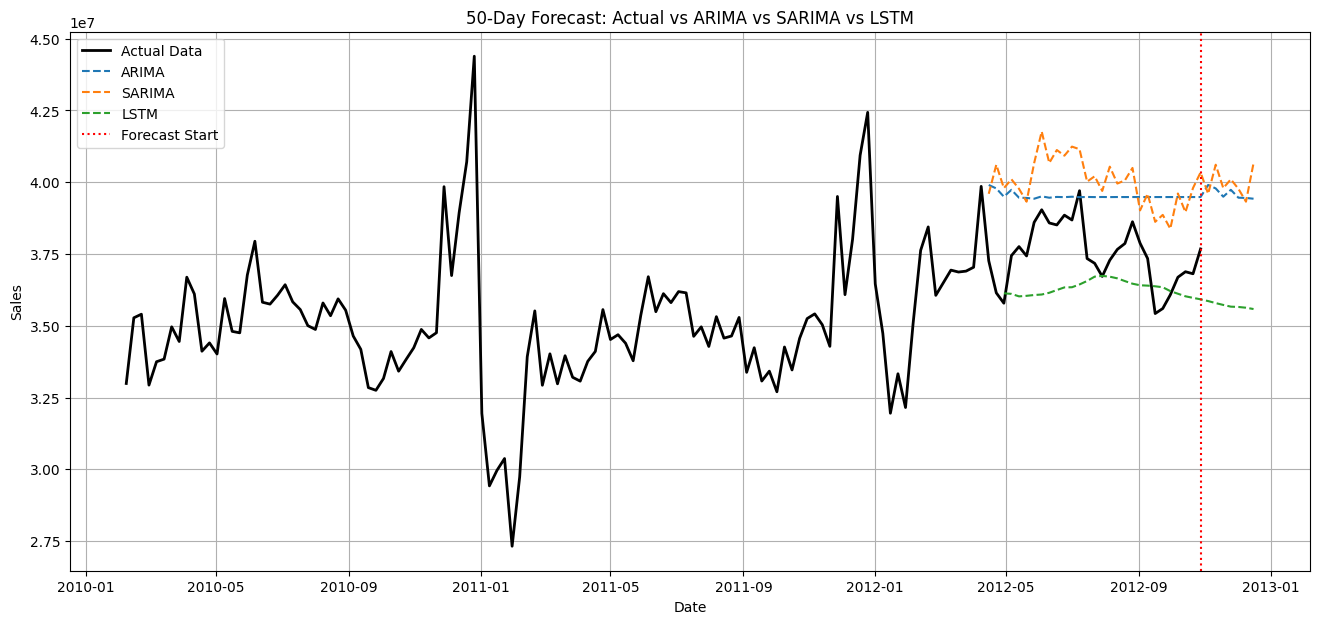

In [36]:
plt.figure(figsize=(16,7))

# Actual data
plt.plot(ts, label='Actual Data', color='black', linewidth=2)

# Models
plt.plot(arima_full, label='ARIMA', linestyle='--')
plt.plot(sarima_full, label='SARIMA', linestyle='--')
plt.plot(lstm_full, label='LSTM', linestyle='--')

# Forecast boundary
plt.axvline(x=ts.index[-1], color='red', linestyle=':', label='Forecast Start')

# Labels
plt.title("50-Day Forecast: Actual vs ARIMA vs SARIMA vs LSTM")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()

plt.show()

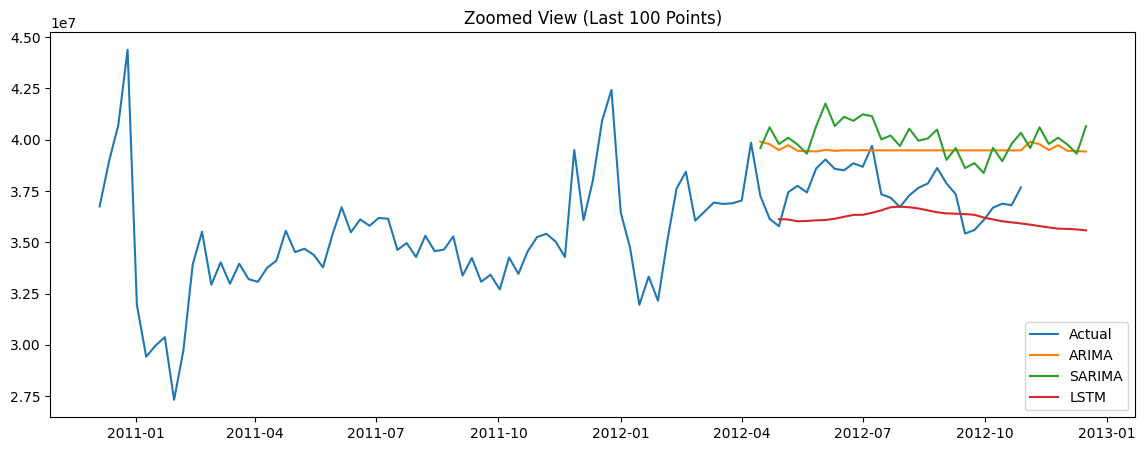

In [37]:
plt.figure(figsize=(14,5))

plt.plot(ts[-100:], label='Actual')
plt.plot(arima_full[-100:], label='ARIMA')
plt.plot(sarima_full[-100:], label='SARIMA')
plt.plot(lstm_full[-100:], label='LSTM')

plt.title("Zoomed View (Last 100 Points)")
plt.legend()
plt.show()

In [38]:
save_path = "/content/drive/MyDrive/Wallmart"

In [39]:
import os
import pickle

# Create folder if not exists
os.makedirs(save_path, exist_ok=True)

#  SARIMA model
pickle.dump(sarima_result, open(f"{save_path}/sarima_model.pkl", "wb"))

#  LSTM model
model.save(f"{save_path}/lstm_model.keras")

#  Scaler
pickle.dump(scaler, open(f"{save_path}/scaler.pkl", "wb"))

#  Last values (for prediction)
ts[-10:].to_csv(f"{save_path}/last_values.csv")

print(" All files saved to Google Drive successfully!")

 All files saved to Google Drive successfully!


TensorFlow: 2.19.0
Keras: 3.13.2
NumPy: 2.0.2
